In [1]:
%load_ext autoreload
%autoreload 2

In [36]:
from pathlib import Path
from utils.ekf_utils import *
from utils.plot_data import *

In [3]:
sim_num = 0
dataset_num = 2
data = load_custom_dataset(dataset_path=Path.cwd().parent / f"custom_datasets/quad_dataset_run{dataset_num}.npz", sim_num=sim_num)

Data loaded from /home/jad/Uni/semester-2/RL-IP/mpx/custom_datasets/quad_dataset_run2.npz.


In [37]:
start = 0
end = len(data["dt"])

result = run_state_estimation(dt=data["dt"][0],
                              init_pos=data["base_pos"][0],
                              base_orient=data["base_orient"],
                              base_ang_vel=data["base_ang_vel"],
                              joint_pos=data["joint_pos"],
                              joint_vel=data["joint_vel"],
                              joint_acc=data["joint_acc"],
                              contact_states=data["contact_states"],
                              contact_forces=data["contact_forces"],
                              contact_pos=data["contact_pos"],
                              Q=0.002, 
                              R=[0.01, 0.01, 0.01])

Estimating base_acc.


Estimating state: 100%|██████████| 5000/5000 [00:06<00:00, 832.23it/s] 


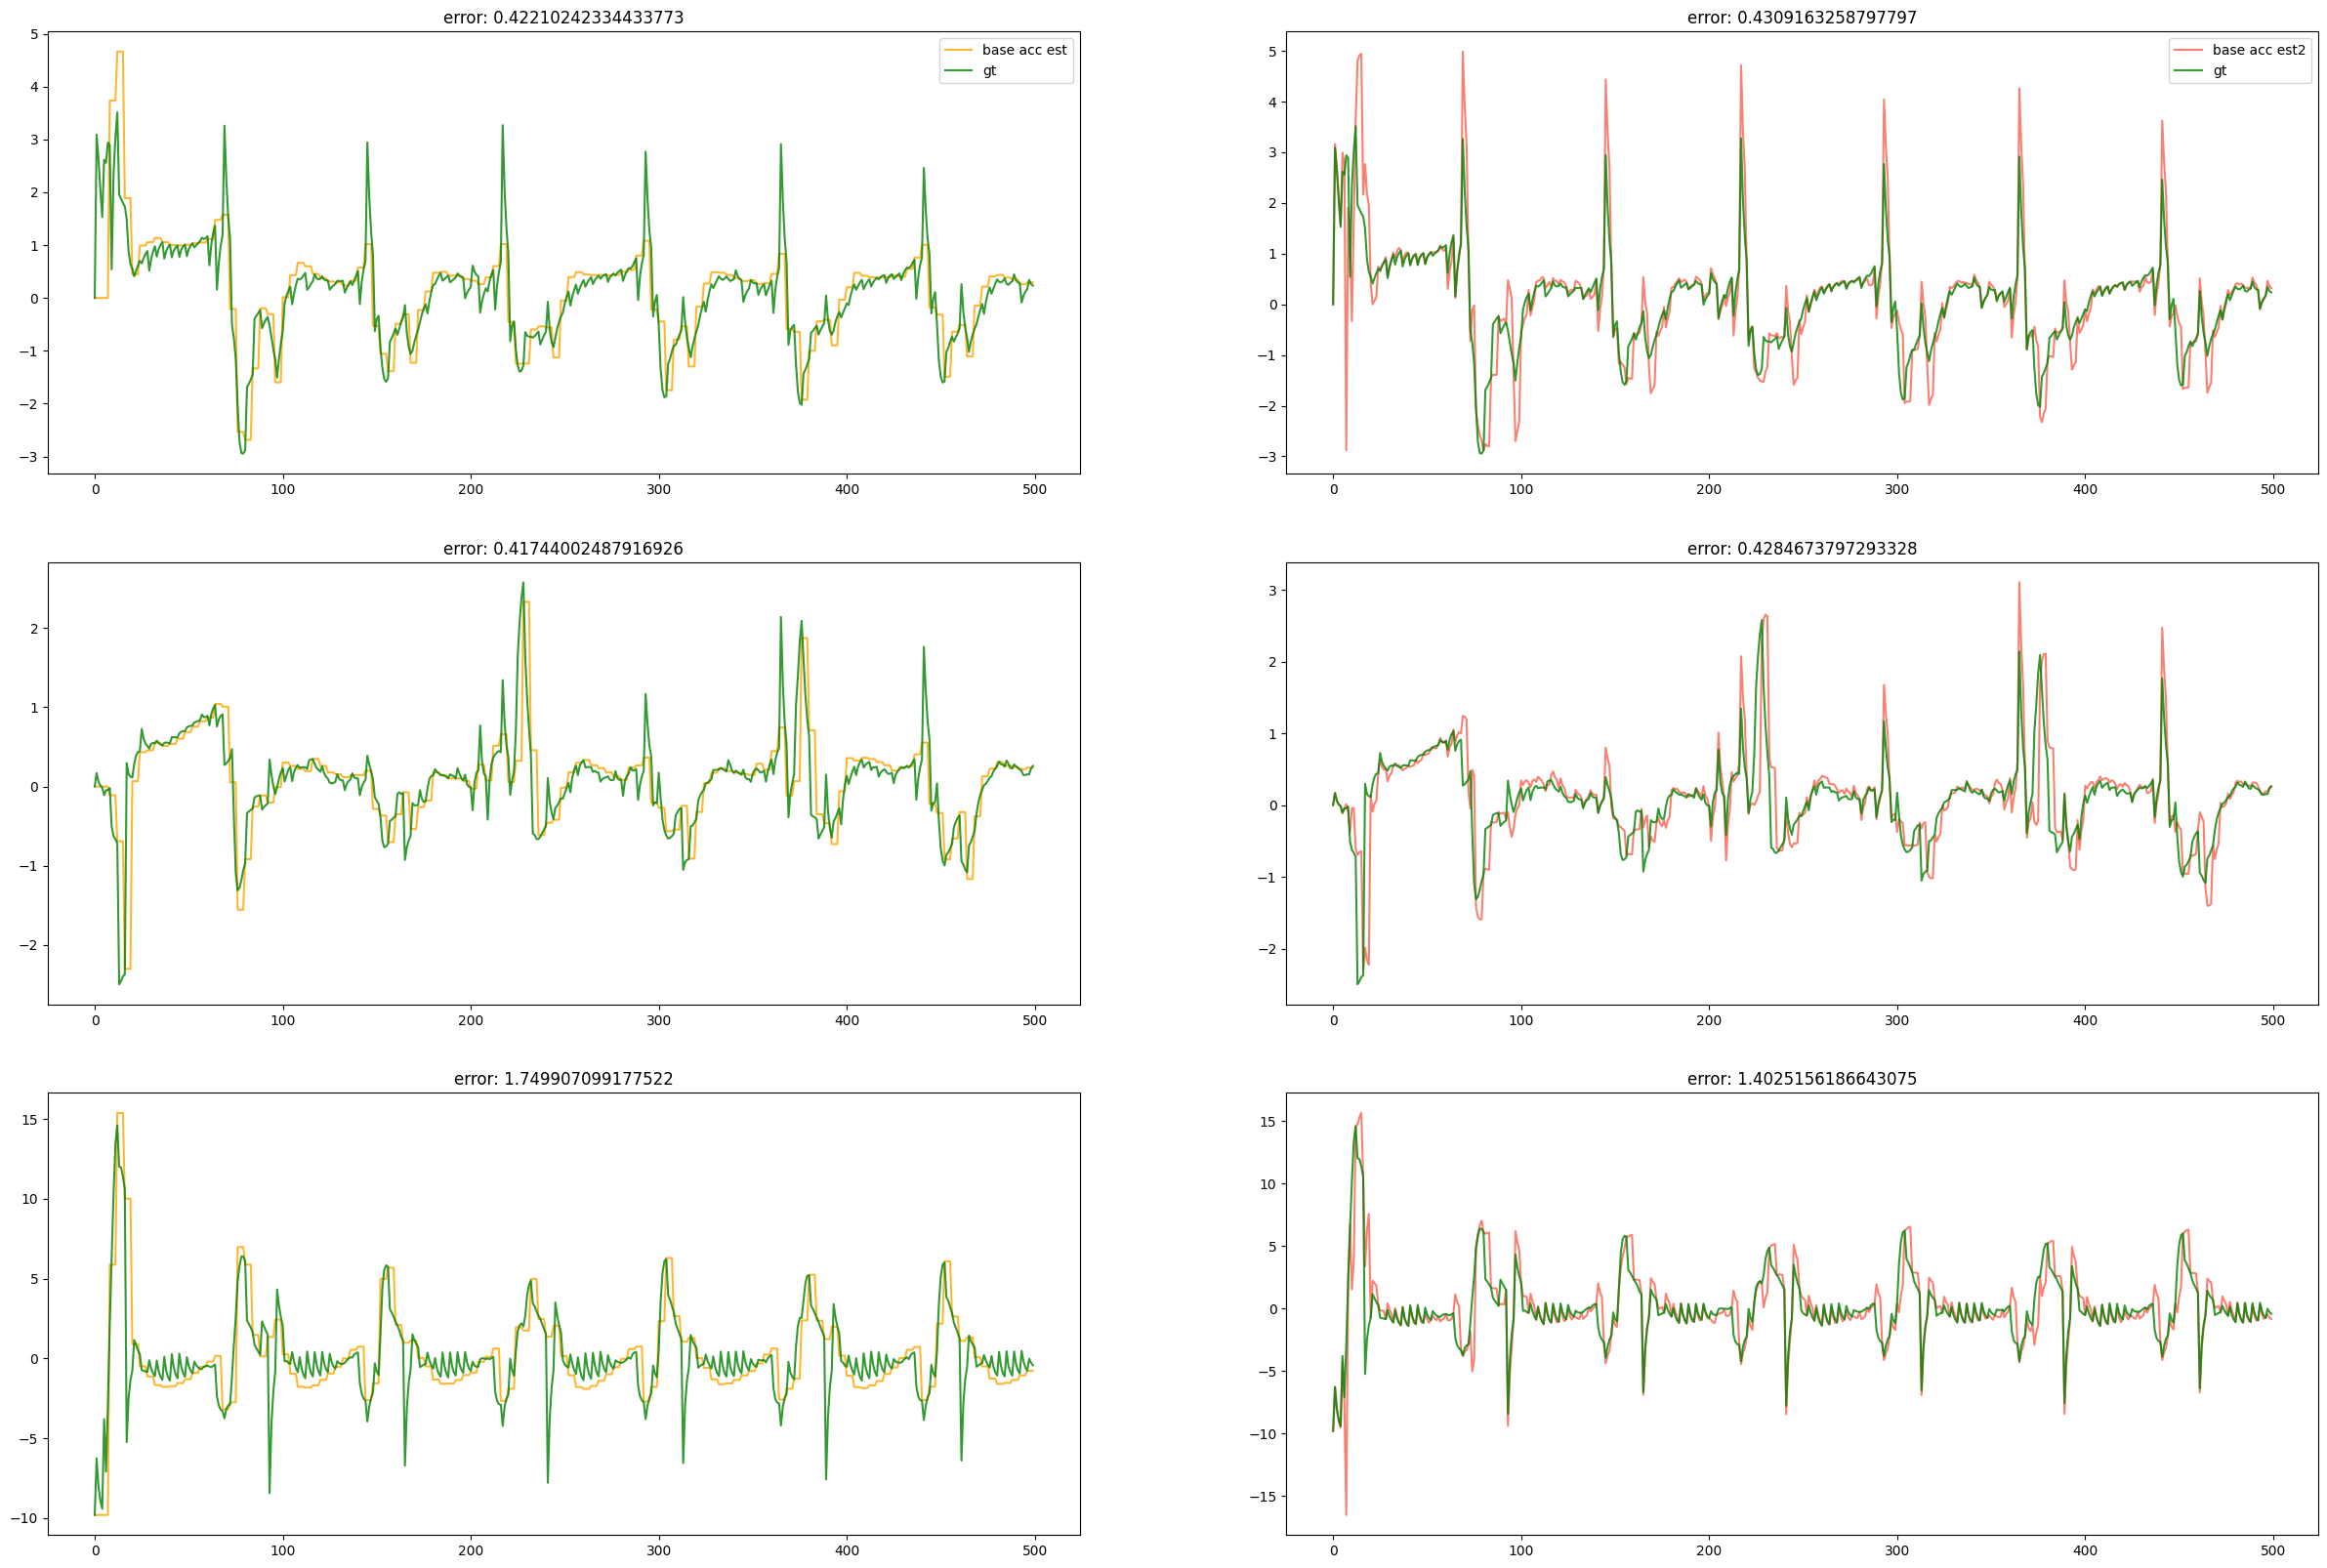

In [40]:
fig, axes = plt.subplots(3, 2, figsize=(30,20))

est_1 = result["base_acc_est"]
est_2 = result["base_acc2_est"]
gt = data["base_acc"]
num_point = 500

for i in range(3):
    axes[i][0].plot(np.arange(num_point), est_1[:num_point, i], label="base acc est", alpha=0.8, color="orange")
    axes[i][1].plot(np.arange(num_point), est_2[:num_point, i], label="base acc est2", color="salmon")

    axes[i][0].plot(np.arange(num_point), gt[:num_point, i], label="gt", alpha=0.8, color="green")
    axes[i][1].plot(np.arange(num_point), gt[:num_point, i], label="gt", alpha=0.8, color="green")

    error_1 = np.sqrt(np.mean((gt[:,i] - est_1[:, i])**2, axis=0))
    error_2 = np.sqrt(np.mean((gt[:,i] - est_2[:, i])**2, axis=0))

    axes[i][0].set_title(f"error: {error_1}")
    axes[i][1].set_title(f"error: {error_2}")

for col in range(2):
    handles, labels = axes[0, col].get_legend_handles_labels()
    axes[0, col].legend(handles, labels, loc="upper right")

plt.show()

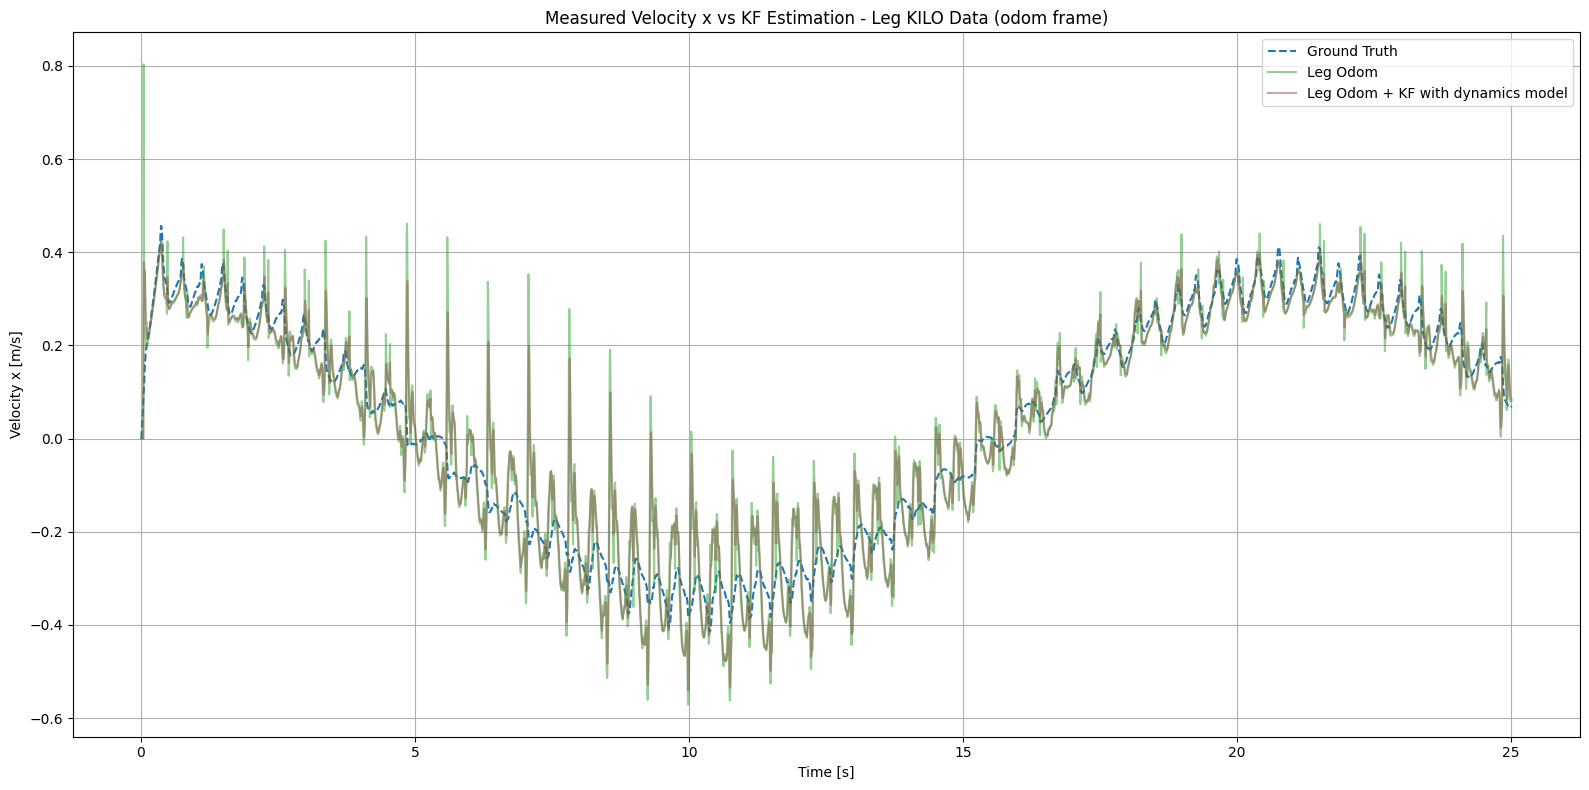

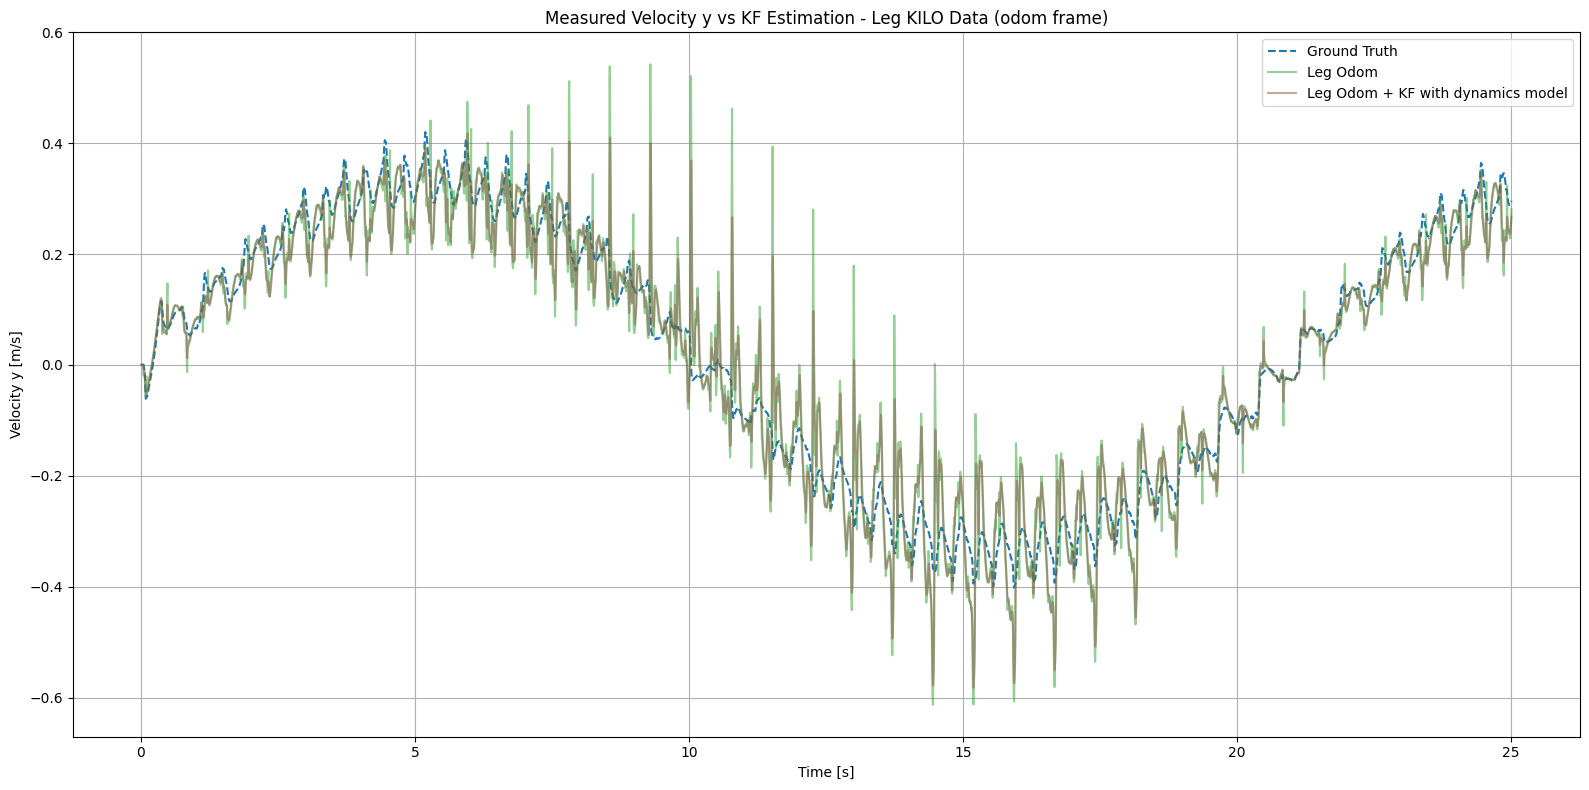

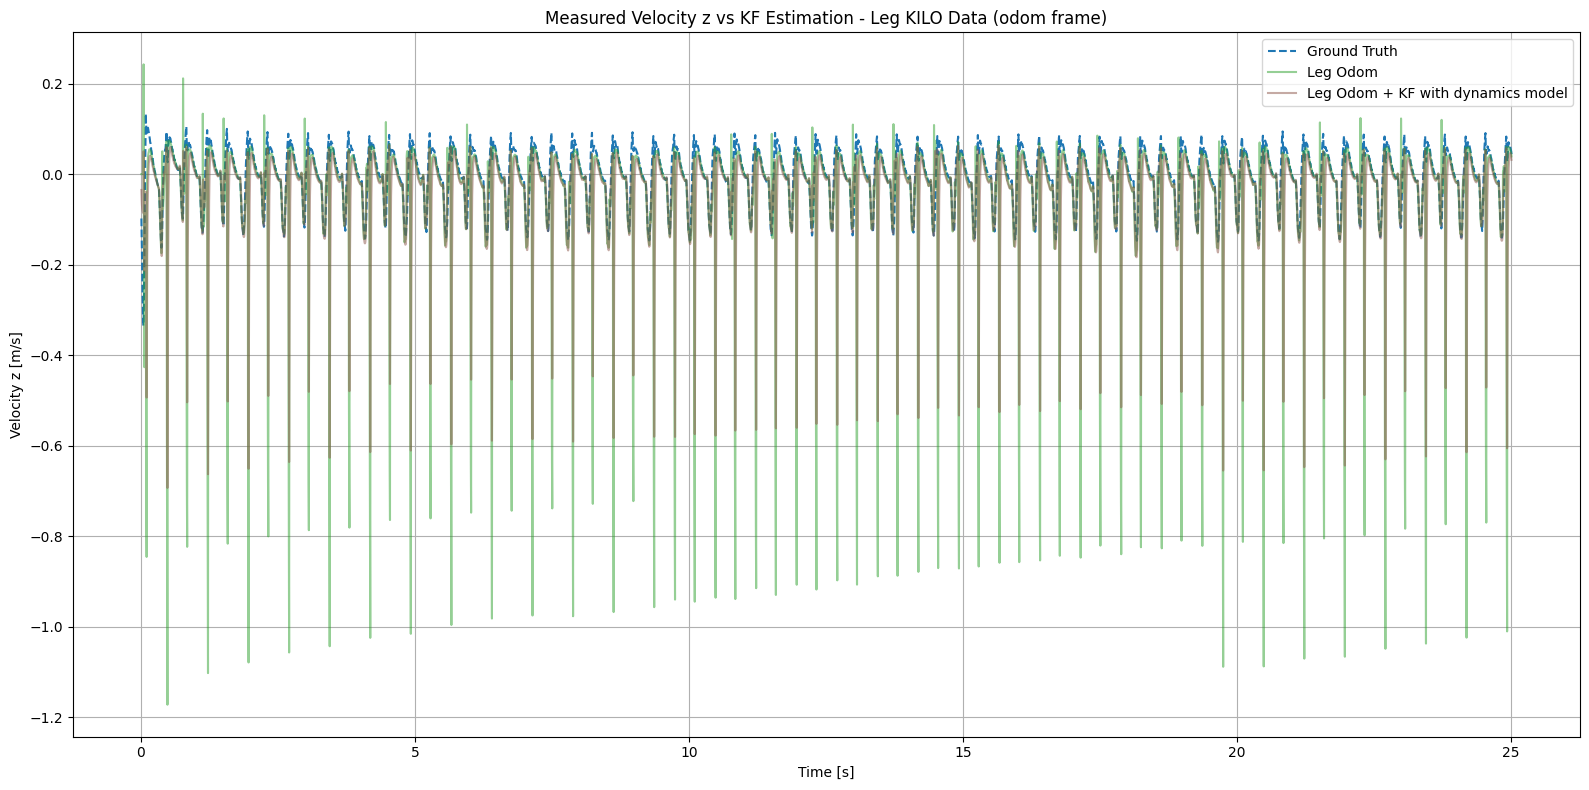

In [39]:
# Odom frame

colors = ['#1f77b4', # gt
        '#2ca02c', # leg odom
        '#8c564b'  # leg odom + kf, dynamics with est cf
        ]

dim = ["x", "y", "z"]
num_data_points = len(data["dt"])

for i in range(len(dim)):
    gt_values = data["base_vel"][:num_data_points, i:i+1]

    pred_values = [result["leg_odom"][:num_data_points, i:i+1],
                   result["vel_update"][:num_data_points, i:i+1]]

    pred_labels = ["Leg Odom", "Leg Odom + KF with dynamics model"]

    compare_estimation_plot(time=data["time"][:num_data_points],
                            gt_values=gt_values,
                            gt_label=["Ground Truth"],
                            pred_values=pred_values,
                            pred_labels=pred_labels,
                            ylabel=f"Velocity {dim[i]} [m/s]",
                            title=f"Measured Velocity {dim[i]} vs KF Estimation - Leg KILO Data (odom frame)",
                            colors=colors
                            )